1. Configurando ambiente Spark

In [27]:
import os
os.environ["PYSPARK_SUBMIT_ARGS"] = "--master local[2] pyspark-shell"

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

try:
    spark.stop()
except:
    pass

spark = SparkSession.builder \
    .appName("ifood-analysis") \
    .config(
        "spark.jars.packages",
        "org.apache.hadoop:hadoop-aws:3.3.4,"
        "io.delta:delta-spark_2.12:3.2.0"
    ) \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .config("spark.hadoop.fs.s3a.endpoint", "http://minio:9000") \
    .config("spark.hadoop.fs.s3a.access.key", "admin") \
    .config("spark.hadoop.fs.s3a.secret.key", "admin123") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .config("spark.sql.parquet.enableVectorizedReader", "false") \
    .config("spark.sql.parquet.int96RebaseModeInRead", "CORRECTED") \
    .config("spark.sql.parquet.datetimeRebaseModeInRead", "CORRECTED") \
    .config("spark.sql.shuffle.partitions", "8") \
    .master("local[2]") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("Spark pronto!")

Spark pronto!


2. Respondendo a primeira pergunta do case:
   Qual a média do valor mensal de corridas, considerando todos os yellow táxis da frota? 

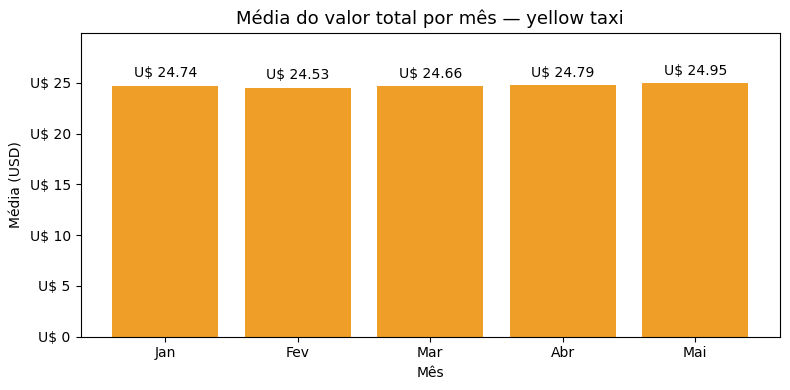

,mes_nome,avg_total_amount,total_corridas
0,Jan,24.74,2785459
1,Fev,24.53,2632878
2,Mar,24.66,3028971
3,Abr,24.79,2901637
4,Mai,24.95,2959953


In [33]:
df_month = spark.read.format("delta") \
    .load("s3a://ifood-data-lake/gold/avg_total_by_month") \
    .orderBy("month") \
    .toPandas()

# Converte month para int antes de mapear
df_month["month"] = df_month["month"].astype(int)

MESES = {1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai"}
df_month["mes_nome"] = df_month["month"].map(MESES)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(df_month["mes_nome"], df_month["avg_total_amount"], color="#EF9F27")
ax.bar_label(bars, fmt="U$ %.2f", padding=4, fontsize=10)
ax.set_title("Média do valor total por mês — yellow taxi", fontsize=13)
ax.set_xlabel("Mês")
ax.set_ylabel("Média (USD)")
ax.set_ylim(0, df_month["avg_total_amount"].max() * 1.2)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("U$ %.0f"))
plt.tight_layout()
plt.savefig("/home/jovyan/work/analysis/p1_avg_total_by_month.png", dpi=150)
plt.show()

df_month[["mes_nome", "avg_total_amount", "total_corridas"]]

3. Média de passageiros por hora do dia no mês de maio, considerando toda a frota de taxis

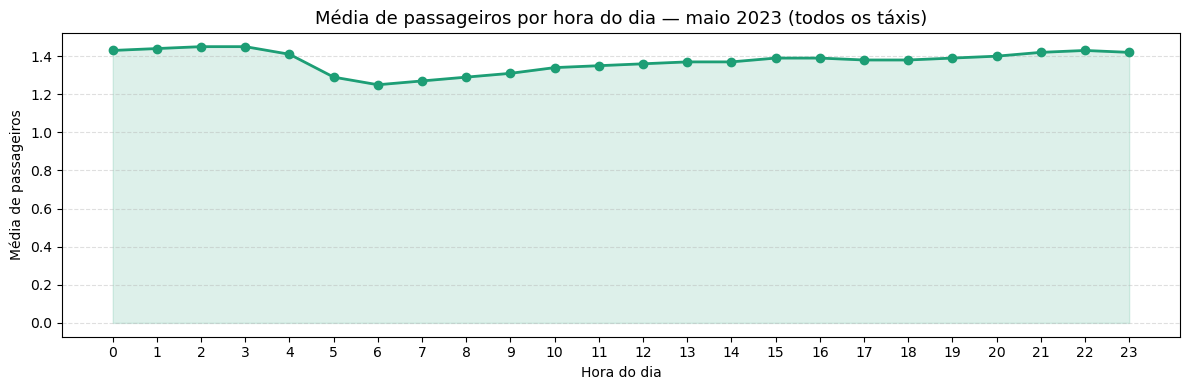

,hour,avg_passengers,total_corridas
0,0,1.43,85817
1,1,1.44,56779
2,2,1.45,36852
3,3,1.45,24041
4,4,1.41,15514
5,5,1.29,17029
6,6,1.25,40572
7,7,1.27,83812
8,8,1.29,114589
9,9,1.31,129461


In [34]:
df_hour = spark.read.format("delta") \
    .load("s3a://ifood-data-lake/gold/avg_passengers_by_hour") \
    .orderBy("hour") \
    .toPandas()

df_hour["hour"] = df_hour["hour"].astype(int)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_hour["hour"], df_hour["avg_passengers"], marker="o", color="#1D9E75", linewidth=2)
ax.fill_between(df_hour["hour"], df_hour["avg_passengers"], alpha=0.15, color="#1D9E75")
ax.set_title("Média de passageiros por hora do dia — maio 2023 (todos os táxis)", fontsize=13)
ax.set_xlabel("Hora do dia")
ax.set_ylabel("Média de passageiros")
ax.set_xticks(range(0, 24))
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("/home/jovyan/work/analysis/p2_avg_passengers_by_hour.png", dpi=150)
plt.show()

df_hour[["hour", "avg_passengers", "total_corridas"]]

4. Volume de corridas e ticket médio ao comparar os yellow aos green taxis

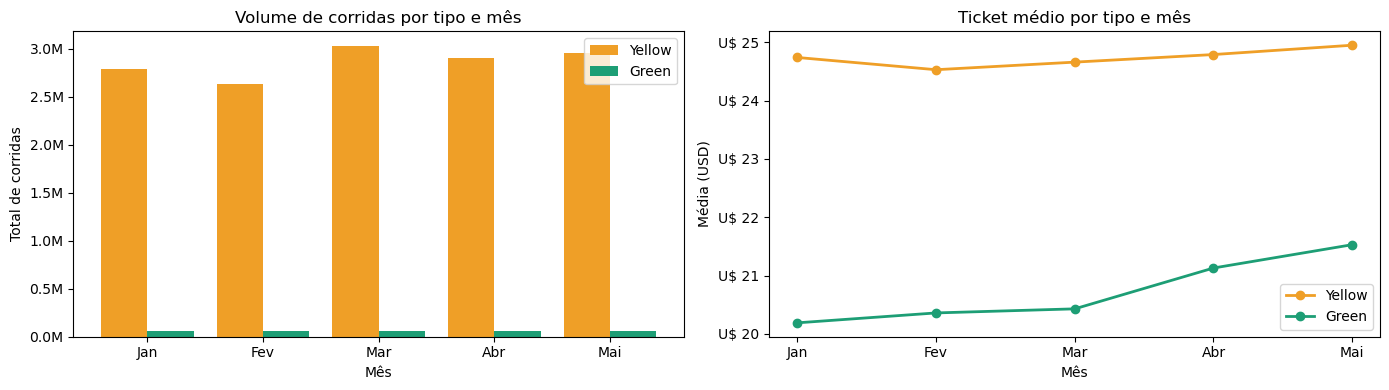

,taxi_type,mes_nome,total_corridas,avg_total_amount,avg_passengers
0,green,Jan,61356,20.19,1.32
1,green,Fev,57387,20.36,1.30
2,green,Mar,64095,20.43,1.30
3,green,Abr,57658,21.13,1.29
4,green,Mai,58542,21.53,1.28
5,yellow,Jan,2785459,24.74,1.38
6,yellow,Fev,2632878,24.53,1.37
7,yellow,Mar,3028971,24.66,1.37
8,yellow,Abr,2901637,24.79,1.40
9,yellow,Mai,2959953,24.95,1.38


In [35]:
df_type = spark.read.format("delta") \
    .load("s3a://ifood-data-lake/gold/trips_by_taxi_type") \
    .toPandas()

df_type["month"] = df_type["month"].astype(int)

MESES = {1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai"}
df_type["mes_nome"] = df_type["month"].map(MESES)

yellow = df_type[df_type["taxi_type"] == "yellow"].sort_values("month")
green  = df_type[df_type["taxi_type"] == "green"].sort_values("month")

x = range(5)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Volume de corridas
axes[0].bar([i - 0.2 for i in x], yellow["total_corridas"], width=0.4, label="Yellow", color="#EF9F27")
axes[0].bar([i + 0.2 for i in x], green["total_corridas"],  width=0.4, label="Green",  color="#1D9E75")
axes[0].set_title("Volume de corridas por tipo e mês", fontsize=12)
axes[0].set_xlabel("Mês")
axes[0].set_ylabel("Total de corridas")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels([MESES[i+1] for i in x])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M"))
axes[0].legend()

# Ticket médio
axes[1].plot(list(x), yellow["avg_total_amount"], marker="o", color="#EF9F27", label="Yellow", linewidth=2)
axes[1].plot(list(x), green["avg_total_amount"],  marker="o", color="#1D9E75", label="Green",  linewidth=2)
axes[1].set_title("Ticket médio por tipo e mês", fontsize=12)
axes[1].set_xlabel("Mês")
axes[1].set_ylabel("Média (USD)")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels([MESES[i+1] for i in x])
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter("U$ %.0f"))
axes[1].legend()

plt.tight_layout()
plt.savefig("/home/jovyan/work/analysis/bonus1_trips_by_taxi_type.png", dpi=150)
plt.show()

df_type[["taxi_type", "mes_nome", "total_corridas", "avg_total_amount", "avg_passengers"]]

5. Horário de pico organizado por tipo de táxi

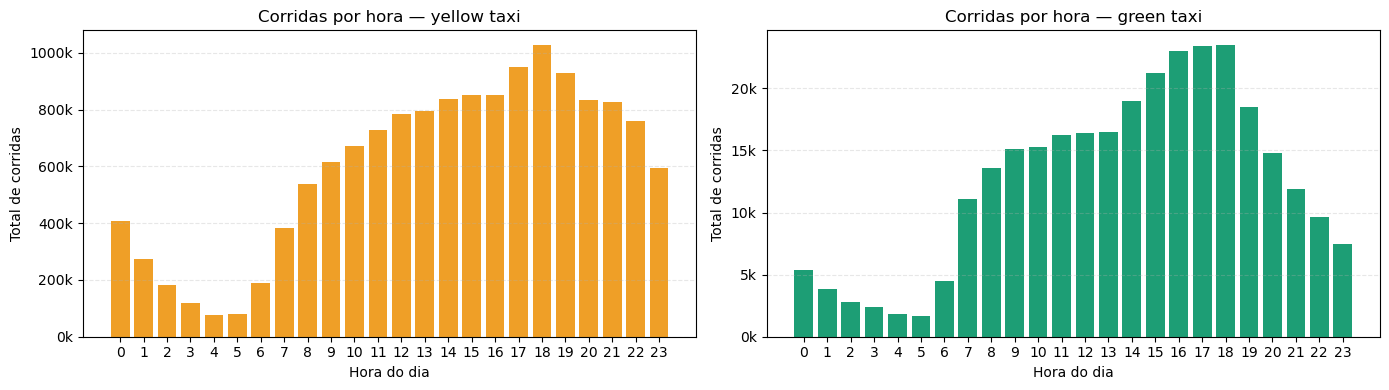

In [36]:
df_peak = spark.read.format("delta") \
    .load("s3a://ifood-data-lake/gold/top_hours_by_taxi_type") \
    .toPandas()

df_peak["hour"] = df_peak["hour"].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, taxi, cor in zip(axes, ["yellow", "green"], ["#EF9F27", "#1D9E75"]):
    dados = df_peak[df_peak["taxi_type"] == taxi].sort_values("hour")
    ax.bar(dados["hour"], dados["total_corridas"], color=cor)
    ax.set_title(f"Corridas por hora — {taxi} taxi", fontsize=12)
    ax.set_xlabel("Hora do dia")
    ax.set_ylabel("Total de corridas")
    ax.set_xticks(range(0, 24))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e3:.0f}k"))
    ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("/home/jovyan/work/analysis/bonus2_peak_hours.png", dpi=150)
plt.show()

6. Encerrando Spark

In [37]:
spark.stop()
print("Análise concluída!")

Análise concluída!
